# Physical Basis of SST Measurements

## Motivation

Sea surface temperature (SST) is a major indicator of physical and biological ocean processes. It reflects the combined influence of air temperature, solar heating, nighttime cooling, evaporative cooling, wind mixing, and wave mixing near the air-ocean interface.

Satellite SST products allow us to assess changes in ocean temperature across large spatial scales and through time. However, satellite-derived SST is not a direct measurement of the full upper ocean. It is inferred from electromagnetic radiation emitted from the very surface of the ocean.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Matplotlib is building the font cache; this may take a moment.


## Key Questions

- How can we relate infrared emission from the ocean surface to ocean temperature?
- What portion of the infrared spectrum can be observed by satellites?
- How much of the ocean surface emits the infrared radiation observed by satellites?

## Ocean Temperature and Electromagnetic Radiation

The ocean surface, like all objects with a temperature above absolute zero, emits electromagnetic radiation. For many introductory remote sensing applications, the ocean surface can be approximated as a **blackbody** that absorbs and emits thermal infrared radiation.

The wavelength at which a blackbody emits its peak radiation is related to its temperature by **Wien's Law**:

$$\lambda_{peak} = \frac{b}{T}$$

where:

- $\lambda_{peak}$ is the peak emission wavelength in meters
- $T$ is temperature in Kelvin
- $b = 2.898 \times 10^{-3}$ m K is Wien's displacement constant

Warmer objects emit more radiation overall and reach their peak emission at shorter wavelengths. Cooler objects emit less radiation overall and reach their peak emission at longer wavelengths.

In [2]:
# Wien's Law calculation for a typical Monterey Bay ocean temperature
b = 2.898e-3  # Wien displacement constant (m K)

# Example ocean temperature
T_ocean_C = 12  # degrees C
T_ocean_K = T_ocean_C + 273.15

lambda_peak_m = b / T_ocean_K
lambda_peak_um = lambda_peak_m * 1e6

print(f'Ocean temperature: {T_ocean_C:.1f} °C = {T_ocean_K:.2f} K')
print(f'Peak wavelength: {lambda_peak_um:.2f} µm')

Ocean temperature: 12.0 °C = 285.15 K
Peak wavelength: 10.16 µm


For typical ocean temperatures, the peak emission occurs in the **thermal infrared**. This is why infrared observations are central to satellite SST retrievals.

### Check Your Understanding

Use Wien's Law to calculate the peak wavelength emitted by ocean water at another temperature. For example, try 8 °C, 15 °C, or 20 °C.

In [3]:
# Try your own temperature here
T_test_C = 15
T_test_K = T_test_C + 273.15
lambda_test_um = (b / T_test_K) * 1e6

print(f'At {T_test_C:.1f} °C, peak emission occurs near {lambda_test_um:.2f} µm.')

At 15.0 °C, peak emission occurs near 10.06 µm.


## Planck's Law and Ocean Thermal Emission

Wien's Law tells us where the peak emission occurs. Planck's Law describes the full emission spectrum of a blackbody:

$$B(\lambda, T) = \frac{2hc^2}{\lambda^5}\frac{1}{e^{hc/(\lambda k_B T)} - 1}$$

where:

- $B(\lambda, T)$ is spectral radiance
- $h$ is Planck's constant
- $c$ is the speed of light
- $k_B$ is the Boltzmann constant
- $\lambda$ is wavelength
- $T$ is temperature

Planck's Law describes the spectral radiance of a blackbody, meaning the amount of energy emitted at each individual wavelength. By integrating Planck's Law across all wavelengths, we obtain the total emitted energy flux per unit area, described by the Stefan-Boltzmann Law.

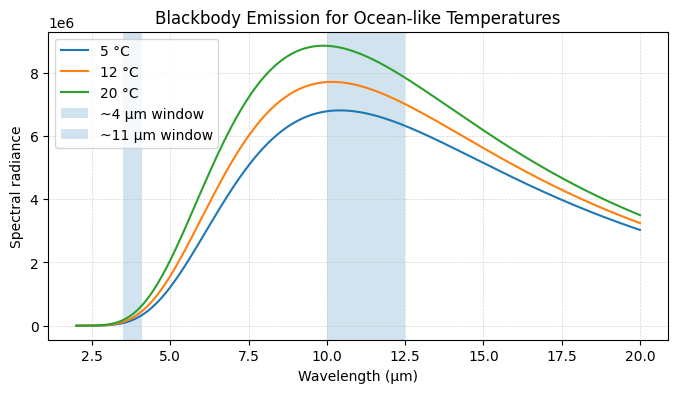

In [4]:
def plancks_law(wavelength_m, temperature_K):
    """Return blackbody spectral radiance as a function of wavelength and temperature."""
    c = 2.9979e8      # speed of light (m/s)
    h = 6.626e-34     # Planck constant (J s)
    kB = 1.380e-23    # Boltzmann constant (J/K)
    return (2*h*c**2 / wavelength_m**5) * (1 / (np.exp(h*c/(wavelength_m*kB*temperature_K)) - 1))

# Wavelengths from 2-20 µm converted to meters
wavelength_um = np.linspace(2, 20, 1000)
wavelength_m = wavelength_um * 1e-6

temperatures_C = [5, 12, 20]
temperatures_K = [T + 273.15 for T in temperatures_C]

plt.figure(figsize=(8, 4))
for T_C, T_K in zip(temperatures_C, temperatures_K):
    radiance = plancks_law(wavelength_m, T_K)
    plt.plot(wavelength_um, radiance, label=f'{T_C} °C')

plt.axvspan(3.5, 4.1, alpha=0.2, label='~4 µm window')
plt.axvspan(10.0, 12.5, alpha=0.2, label='~11 µm window')
plt.xlabel('Wavelength (µm)')
plt.ylabel('Spectral radiance')
plt.title('Blackbody Emission for Ocean-like Temperatures')
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend()
plt.show()

## Atmospheric Windows in the Thermal Infrared

For visible remote sensing, we often ask how much sunlight can travel downward through the atmosphere, reflect from the ocean, and travel back to the satellite.

For thermal infrared SST retrievals, we ask a different question: **how much radiation emitted upward from the ocean surface can pass through the atmosphere to the satellite?**

The atmosphere absorbs strongly at many infrared wavelengths, especially due to water vapor. SST algorithms therefore focus on atmospheric windows where a relatively large fraction of ocean-emitted thermal radiation reaches the satellite.

Two important thermal infrared regions for SST are near:

- **4 µm**, often useful at night because daytime sun glint can overwhelm the thermal signal
- **11 µm**, widely used for day and night SST retrievals

There is a trade-off: the 4 µm region can have lower water-vapor impact, but the ocean emits much less energy there than near 11 µm for Earth-like temperatures.

## Thermal Infrared Absorption at the Ocean Surface

Infrared radiation is absorbed very quickly by liquid water. The thermal infrared radiation observed by satellites is emitted from approximately the upper **1 µm** of the ocean.

This means satellite infrared SST is a measurement of the ocean **skin temperature**, not the temperature of the full upper mixed layer.

## Skin SST vs Bulk SST

**Skin SST** refers to the temperature of the very surface of the ocean inferred from emitted infrared radiation.

**Bulk SST** refers to temperatures measured deeper in the upper ocean, often in the top meter, using in situ instruments or represented in models.

Skin and bulk SST can differ by about ±1 K or more depending on mixing, wind speed, solar heating, nighttime cooling, and stratification. In daytime, the skin may be biased slightly warm under strong solar heating. At night, the skin is often slightly cooler because of heat loss from the surface.

### Summary

Satellite SST retrievals rely on the relationship between temperature and thermal infrared emission. Because infrared radiation comes from only the ocean skin and must pass through the atmosphere, satellite SST is not a simple direct measurement of bulk upper-ocean temperature.

Key ideas:

1. Ocean-like temperatures emit peak radiation in the thermal infrared.
2. Infrared SST retrievals measure the ocean skin, not the full upper mixed layer.